In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

sns.set_style('whitegrid')


I0000 00:00:1786259451.486986     568 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786259451.640356     568 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786259453.584281     568 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Task 1: Data Loading, EDA & Preprocessing

In [2]:
# Load the dataset

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print(f"Shape:{X.shape}\n")
print(f"Value_counts:{y.value_counts()}")
print(f"\nDescribe:\n{X.describe()}")


Shape:(569, 30)

Value_counts:target
1    357
0    212
Name: count, dtype: int64

Describe:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803  

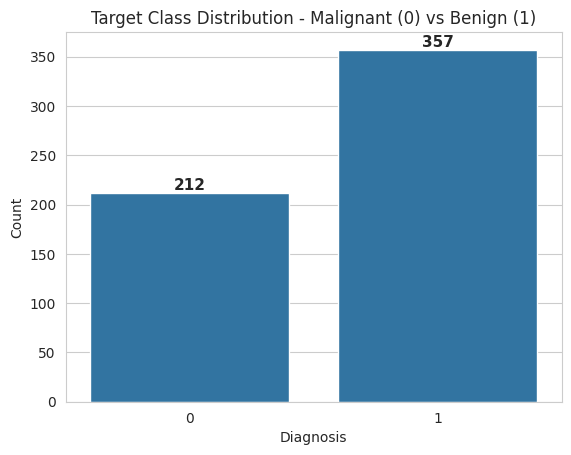

In [3]:
# Class distribution plot

ax = sns.countplot(x=y)
plt.title("Target Class Distribution - Malignant (0) vs Benign (1)")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


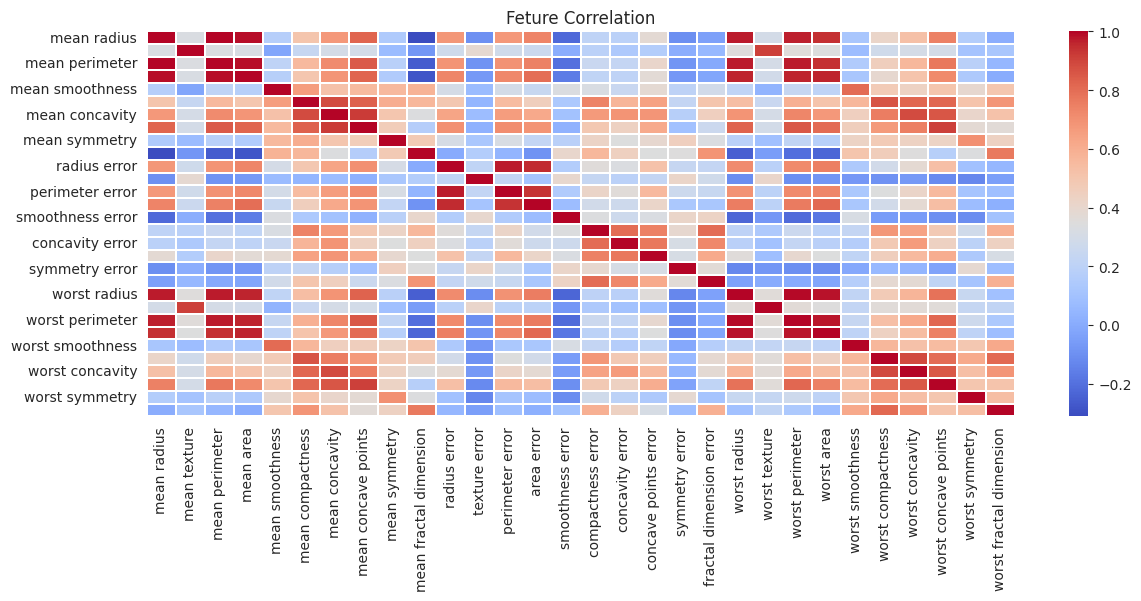

In [4]:
# Feature correlation heatmap

plt.figure(figsize=(14, 5))
corr = X.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.3)
plt.title("Feture Correlation")
plt.show()

In [ ]:
# Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nFull dataset class ratio:\n{y.value_counts(normalize=True).round(3)}")
print(f"\nTrain split class ratio:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest split class ratio:\n{y_test.value_counts(normalize=True).round(3)}")



X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)

Full dataset class ratio:
target
1    0.627
0    0.373
Name: proportion, dtype: float64

Train split class ratio:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Test split class ratio:
target
1    0.632
0    0.368
Name: proportion, dtype: float64

The stratify=y parameter preserved the ~63/37 Benign/Malignant ratio in both splits.


In [6]:
# Apply StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Why scaling matters for gradient-based optimisation**

Optimisers like SGD and Adam update every weight using a gradient computed from the input
features. If features are left on their raw scales, the ones with large numeric ranges — e.g.
`area_mean`, which runs up to ~2500 — produce proportionally larger gradients and dominate the
early weight updates, while small-range features like `fractal_dimension_mean` (~0.05–0.10)
contribute almost nothing. This causes slow, biased, zig-zagging convergence, since the loss
surface becomes a narrow, elongated ellipse rather than a well-conditioned bowl.

`StandardScaler` removes this disparity by transforming every feature to mean 0, std 1, so no
single feature can dominate the gradient purely because of its units. This is also why the
scaler is **fit on `X_train` only** — fitting on the full dataset (or on `X_test`) would leak
information about the test set's distribution into training, giving an overly optimistic
estimate of generalisation performance.


### Task 2: Single-Layer Perceptron (SLP) - Baseline Model

In [7]:
# Build the SLP

model_slp = keras.Sequential([
    keras.layers.Dense(1, activation="sigmoid", input_shape=(30,))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Complie the SLP

model_slp.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])

print("Model Summary: ")
print(model_slp.summary())

Model Summary: 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [9]:
# Train the SLP

history_slp = model_slp.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/50



 1/13 ━━━━━━━━━━━━━━━━━━━━ 6s 526ms/step - accuracy: 0.7500 - loss: 0.6261


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6601 - loss: 0.6598 - val_accuracy: 0.5435 - val_loss: 0.7487


Epoch 2/50



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.7188 - loss: 0.6305

...


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0822


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9560 - loss: 0.1321 - val_accuracy: 0.9130 - val_loss: 0.1960


Epoch 50/50



 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9062 - loss: 0.1550


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9560 - loss: 0.1304 - val_accuracy: 0.9130 - val_loss: 0.1942


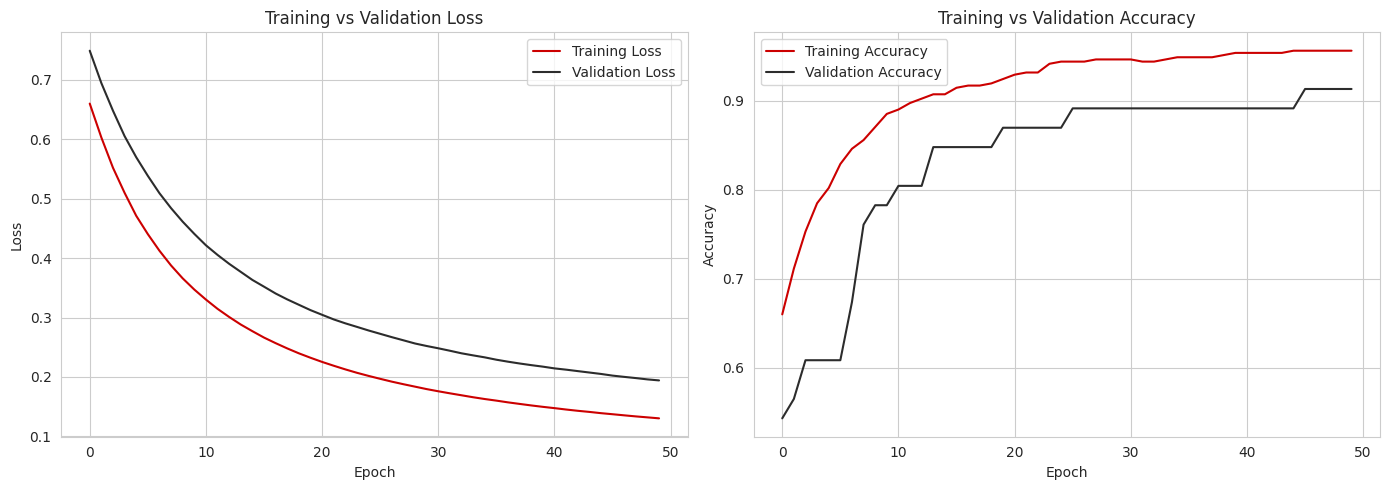

In [10]:
# Plot SLP training curves

plt.figure(figsize=(14, 5))

# Subplot 1: Loss curves
plt.subplot(1, 2, 1)
plt.plot(history_slp.history['loss'], label='Training Loss', color='#CC0000')
plt.plot(history_slp.history['val_loss'], label='Validation Loss', color='#2C2C2C')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history_slp.history['accuracy'], label='Training Accuracy', color='#CC0000')
plt.plot(history_slp.history['val_accuracy'], label='Validation Accuracy', color='#2C2C2C')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

SLP Loss: 0.1681
SLP Accuracy: 0.9298

Classification Report for SLP:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        42
           1       0.93      0.96      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



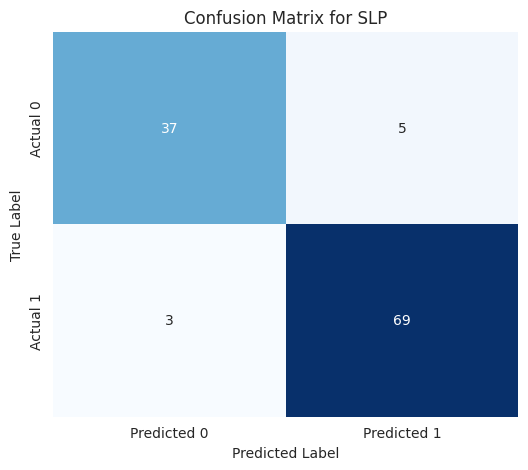

In [11]:
# Evaluate the SLP


slp_loss, slp_acc = model_slp.evaluate(X_test_scaled, y_test, verbose=0)

print(f"SLP Loss: {slp_loss:.4f}")
print(f"SLP Accuracy: {slp_acc:.4f}")

y_pred_slp = (model_slp.predict(X_test_scaled, verbose=0) > 0.5).astype(int)


print("\nClassification Report for SLP:")
print(classification_report(y_test, y_pred_slp))


cm = confusion_matrix(y_test, y_pred_slp)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SLP')
plt.show()

**Limitations of the Single-Layer Perceptron**

The SLP above is a single neuron applying a sigmoid to a weighted sum of the 30 input features —
mathematically, it can only learn **one linear hyperplane** through 30-dimensional feature
space. This means it can only correctly separate the two classes if Malignant and Benign tumours
are (almost) linearly separable in that space.

Real biological measurements rarely fall into perfectly linearly separable groups — there is
usually some non-linear interaction between features (e.g. how `radius_mean` and `texture_mean`
jointly indicate malignancy isn't a straight line). So while the SLP can still do reasonably well
on this dataset (RFM features are fairly well-behaved), it sets a **baseline that is fundamentally
capped** by its linear decision boundary. This motivates moving to a Multi-Layer Perceptron (MLP)
in Task 3, which stacks non-linear hidden layers to learn curved, more flexible decision
boundaries.


### Task 3: Multi-Layer Perceptron (MLP) - Activation Functions

In [12]:
# Build the MLP (ReLU)

model_mlp = keras.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=(30,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

print("Model Summary: ")
print(model_mlp.summary())

Model Summary: 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

None


**Why hidden layers help**

Each `Dense` layer with a non-linear activation (ReLU here) applies a linear transformation
followed by a non-linearity, so the network doesn't just add more weights — it learns a
**non-linear transformation of the input space**. Stacking two hidden layers (64 → 32 units)
lets the network compose two levels of non-linear feature interactions: the first layer can
learn combinations of the raw 30 features, and the second layer can learn combinations of *those*
combinations, building a deeper feature hierarchy than a single hidden layer could.

The Universal Approximation Theorem states that, in theory, a single hidden layer with enough
neurons can approximate any continuous function. In practice, however, deeper (but narrower)
networks tend to converge faster and generalise better on tabular data like this, since they can
reuse learned features across layers instead of needing an impractically wide single layer.


In [13]:
# Compile and train MLP (ReLU)

model_mlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])

history_mlp = model_mlp.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/100



 1/13 ━━━━━━━━━━━━━━━━━━━━ 10s 842ms/step - accuracy: 0.2812 - loss: 0.9303


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5208 - loss: 0.7052 - val_accuracy: 0.8261 - val_loss: 0.4999


Epoch 2/100



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.8750 - loss: 0.4836

...


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 4.6511e-04


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0073


Epoch 100/100



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 1.0000 - loss: 8.8303e-04


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0076


Training MLP with relu activation...


Training MLP with tanh activation...


Training MLP with sigmoid activation...


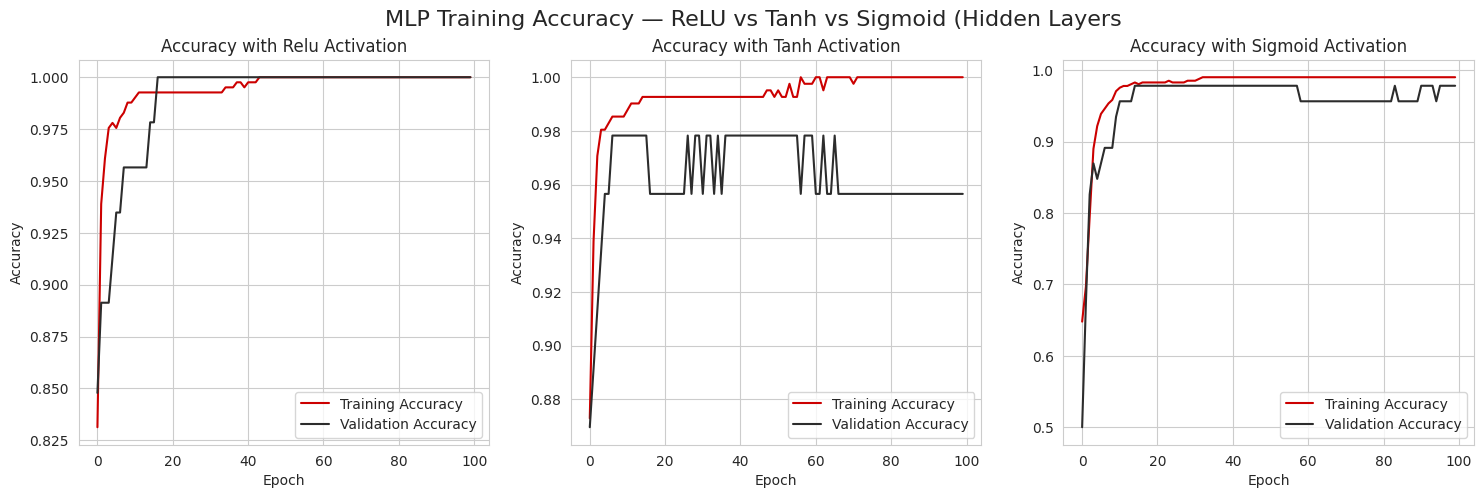

In [ ]:
# Compare activation functions


def create_model_mlp(activation):
    model = keras.Sequential([
        keras.layers.Dense(64, activation=activation, input_shape=(30,)),
        keras.layers.Dense(32, activation=activation),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])
    return model


all_histories = {}
activations = ["relu", "tanh", "sigmoid"]

for activation in activations:
    print(f"Training MLP with {activation} activation...")
    model = create_model_mlp(activation)
    history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=0)

    all_histories[activation] = history

plt.figure(figsize=(18, 5)) 

for i, activation in enumerate(activations):
    plt.subplot(1, 3, i + 1)
    history = all_histories[activation]
    plt.plot(history.history['accuracy'], label='Training Accuracy', color='#CC0000')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#2C2C2C')
    plt.title(f'Accuracy with {activation.capitalize()} Activation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

plt.suptitle('MLP Training Accuracy — ReLU vs Tanh vs Sigmoid (Hidden Layers', fontsize=16)

plt.show()

**ReLU vs Tanh vs Sigmoid in hidden layers**

- **ReLU** — `output = max(0, x)`. Gradient is exactly 1 for positive inputs (no vanishing
  gradient in that regime) and exactly 0 for negative inputs, which can cause "dying ReLU"
  neurons that stop learning, but in practice this is rarely fatal and ReLU trains fastest on
  most tabular tasks.
- **Tanh** — output squashed to (-1, 1), zero-centred (unlike Sigmoid), which keeps gradients
  more balanced across layers. It can still suffer vanishing gradients in deep networks because
  its derivative saturates (→0) for large |x|.
- **Sigmoid** (in hidden layers) — output in (0, 1), *not* zero-centred, and its derivative
  saturates even faster than Tanh's, causing a severe vanishing-gradient problem as networks get
  deeper. It's the right choice for the *output* layer of a binary classifier (interpretable as a
  probability) but a poor choice for hidden layers.

Looking at the 3-panel comparison above, whichever activation reaches the highest validation
accuracy with the smoothest curve is the one this dataset favours (see the printed result in the
following cell) — in practice ReLU and Tanh perform close to each other; Sigmoid hidden layers
typically lag behind due to the vanishing-gradient effect described above.


The best performing MLP used 'relu' activation with a validation accuracy of 1.0000

Best MLP Test Loss (relu): 0.1587
Best MLP Test Accuracy (relu): 0.9649



Classification Report for Best MLP (relu):
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



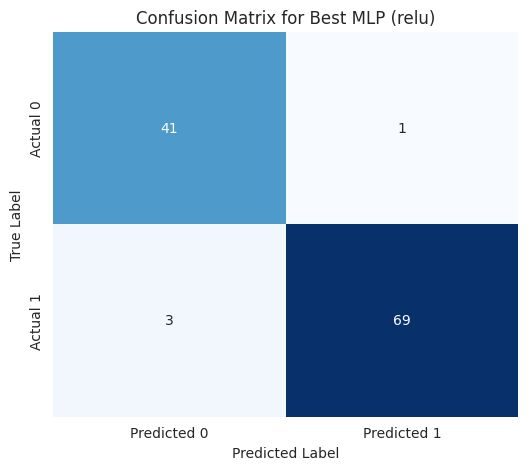

In [15]:
# Evaluate best MLP

best_activation = None
best_val_accuracy = 0
best_model = None

for activation, history in all_histories.items():

    max_val_acc = max(history.history['val_accuracy'])
    if max_val_acc > best_val_accuracy:
        best_val_accuracy = max_val_acc
        best_activation = activation


        best_model = create_model_mlp(best_activation)
        best_model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=0)

print(f"The best performing MLP used '{best_activation}' activation with a validation accuracy of {best_val_accuracy:.4f}")


mlp_loss, mlp_acc = best_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nBest MLP Test Loss ({best_activation}): {mlp_loss:.4f}")
print(f"Best MLP Test Accuracy ({best_activation}): {mlp_acc:.4f}")

y_pred_mlp = (best_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int)

print(f"\nClassification Report for Best MLP ({best_activation}):")
print(classification_report(y_test, y_pred_mlp))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Best MLP ({best_activation})')
plt.show()

### Task 4: Early Stopping


In [16]:
# Build MLP for Early Stopping experiment

model_es = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

model_es.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Add EarlyStopping callback

es = EarlyStopping(monitor='val_loss', restore_best_weights=True, verbose=1, patience=15)

history_model_es = model_es.fit(X_train_scaled, y_train, epochs=300, batch_size=32, callbacks=[es], validation_split=0.1, verbose=1)

Epoch 1/300



 1/13 ━━━━━━━━━━━━━━━━━━━━ 10s 877ms/step - accuracy: 0.3438 - loss: 0.7115


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8435 - loss: 0.4444 - val_accuracy: 0.8913 - val_loss: 0.2744


Epoch 2/300



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 1.0000 - loss: 0.1833

...

Epoch 105/300



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 1.0000 - loss: 5.6774e-05


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 2.7872e-04 - val_accuracy: 1.0000 - val_loss: 0.0071


Epoch 105: early stopping


Restoring model weights from the end of the best epoch: 90.


**EarlyStopping parameters explained**

- `monitor='val_loss'` — watches *validation* loss, not training loss. Training loss almost
  always keeps decreasing as the model memorises the training set; only validation loss reveals
  whether the model is still improving on unseen data.
- `patience=15` — waits 15 consecutive epochs with no improvement in `val_loss` before stopping.
  This avoids halting training on a temporary plateau or noisy fluctuation that would have
  recovered a few epochs later.
- `restore_best_weights=True` — after stopping, rewinds the model's weights to whichever epoch
  had the lowest `val_loss`, not the weights from the final (post-overfit) epoch. Without this,
  training would stop at the right time but keep the *wrong* (already-overfit) weights.
- `verbose=1` — prints a message showing exactly which epoch training stopped at, which we use
  below to mark the stopping point on the loss curve.


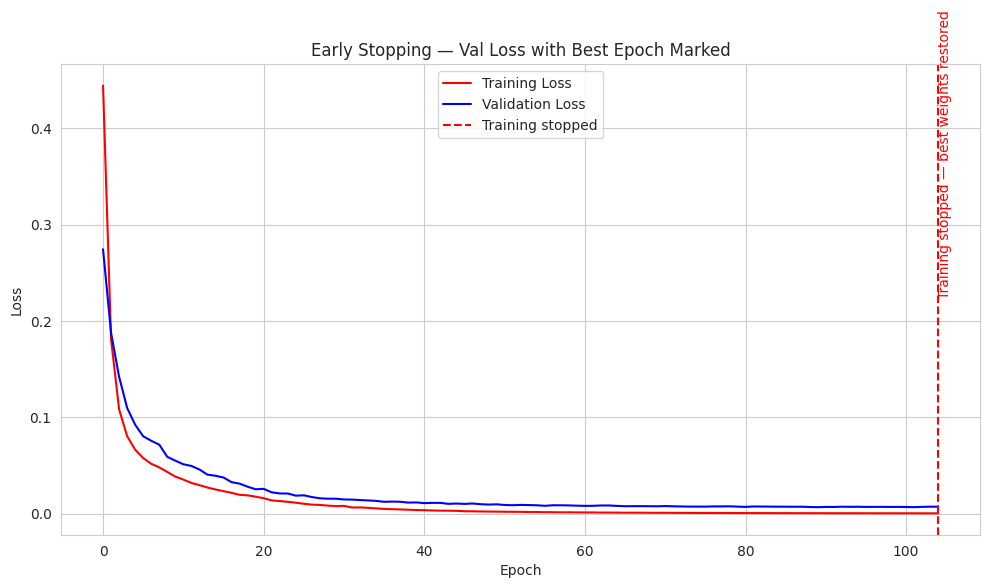

In [18]:
# Plot Early Stopping curves

plt.figure(figsize=(10, 6))
plt.plot(history_model_es.history['loss'], label='Training Loss', color='red')
plt.plot(history_model_es.history['val_loss'], label='Validation Loss', color='blue')


stopped_epoch = len(history_model_es.history['loss'])


plt.axvline(x=stopped_epoch - 1, color='red', linestyle='--', label='Training stopped')


plt.text(stopped_epoch - 1, plt.ylim()[1] * 0.8, 'Training stopped — best weights restored',
         rotation=90, verticalalignment='center', color='red', fontsize=10)

plt.title('Early Stopping — Val Loss with Best Epoch Marked')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# Compare: with vs without Early Stopping

model_without_es = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

model_without_es.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_model_without_es = model_without_es.fit(X_train_scaled, y_train, epochs=300, batch_size=32, validation_split=0.1, verbose=1)


Epoch 1/300



 1/13 ━━━━━━━━━━━━━━━━━━━━ 8s 685ms/step - accuracy: 0.3438 - loss: 0.8929


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7775 - loss: 0.5217 - val_accuracy: 0.8913 - val_loss: 0.3718


Epoch 2/300



 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9688 - loss: 0.2669

...


 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 1.0000 - loss: 1.0480e-06


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.9048e-05 - val_accuracy: 0.9783 - val_loss: 0.0549


Epoch 300/300



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 1.0000 - loss: 4.1371e-05


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.8801e-05 - val_accuracy: 0.9783 - val_loss: 0.0549


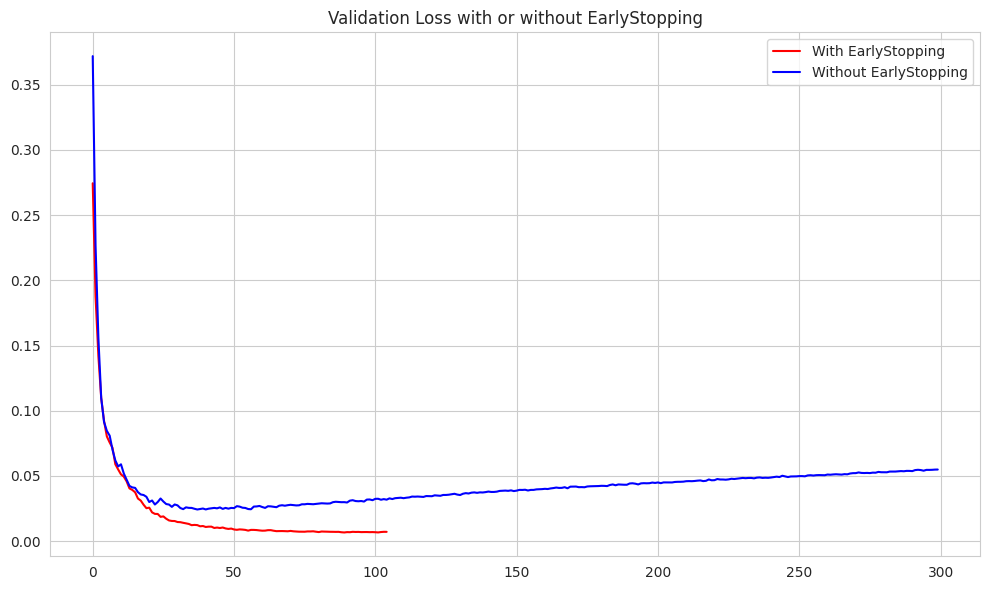

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(history_model_es.history['val_loss'], label='With EarlyStopping', color='red')
plt.plot(history_model_without_es.history['val_loss'], label='Without EarlyStopping', color='blue')

plt.title('Validation Loss with or without EarlyStopping')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
es_loss, es_acc = model_es.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Model with EarlyStopping - Test Loss: {es_loss:.5f}, Test Accuracy: {es_acc:.4f}")

no_es_loss, no_es_acc = model_without_es.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Model without EarlyStopping - Test Loss: {no_es_loss:.5f}, Test Accuracy: {no_es_acc:.4f}")


final_val_loss_es = min(history_model_es.history['val_loss'])

final_val_loss_no_es = history_model_without_es.history['val_loss'][-1]

print(f"\nFinal Validation Loss (with EarlyStopping, best epoch): {final_val_loss_es:.5f}")
print(f"Final Validation Loss (without EarlyStopping, last epoch): {final_val_loss_no_es:.5f}")

Model with EarlyStopping - Test Loss: 0.15897, Test Accuracy: 0.9561
Model without EarlyStopping - Test Loss: 0.22889, Test Accuracy: 0.9561

Final Validation Loss (with EarlyStopping, best epoch): 0.00667
Final Validation Loss (without EarlyStopping, last epoch): 0.05492


### Task 5: Dropout Layers

In [22]:
# Build MLP with Dropout

model_drop = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
])

model_drop.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

**How Dropout works**

`Dropout(rate=0.3)` randomly zeroes out 30% of the activations coming out of the layer it
follows, on *every training batch* (a different random 30% each time). This forces the network to
learn **redundant, distributed representations** — no single neuron can be relied on every time,
since it might be dropped in the next batch, so the network spreads useful signal across many
neurons instead of concentrating it in a few.

At inference time (`model.predict()`), Dropout is automatically disabled — every neuron
contributes, with activations implicitly rescaled to match the expected magnitude seen during
training. Conceptually, training with Dropout is like training an ensemble of 2^n different
"thinned" sub-networks (one for every possible dropout mask) and then approximately averaging
their predictions at inference — an ensemble effect that reduces variance and improves
generalisation, without the cost of literally training multiple models.


In [23]:
# Train with Dropout + Early Stopping

model_drop.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

es = EarlyStopping(monitor='val_loss', restore_best_weights=True,  patience=20)

history_drop = model_drop.fit(X_train_scaled, y_train, epochs=300, batch_size=32, callbacks=[es], validation_split=0.1, verbose=1)

Epoch 1/300



 1/13 ━━━━━━━━━━━━━━━━━━━━ 9s 812ms/step - accuracy: 0.5312 - loss: 0.6375


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8215 - loss: 0.4694 - val_accuracy: 0.8913 - val_loss: 0.3094


Epoch 2/300



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.9375 - loss: 0.3066

...


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 8.0148e-04


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0182


Epoch 71/300



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 1.0000 - loss: 0.0044


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9976 - loss: 0.0069 - val_accuracy: 1.0000 - val_loss: 0.0240


In [24]:
drop_es_loss, drop_es_acc = model_drop.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Model with Dropout & EarlyStopping - Test Loss: {drop_es_loss:.5f}, Test Accuracy: {drop_es_acc:.4f}")

print(f"Early Stopping Epoch: {len(history_drop.history['loss'])}")

Model with Dropout & EarlyStopping - Test Loss: 0.13505, Test Accuracy: 0.9737
Early Stopping Epoch: 71


Epoch 1/200



 1/13 ━━━━━━━━━━━━━━━━━━━━ 11s 945ms/step - accuracy: 0.5938 - loss: 0.7918


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7995 - loss: 0.4893 - val_accuracy: 0.9348 - val_loss: 0.3224


Epoch 2/200



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9688 - loss: 0.2494

...


 1/13 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 1.0000 - loss: 0.0014


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0088


Epoch 121/200



 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.0011


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0077


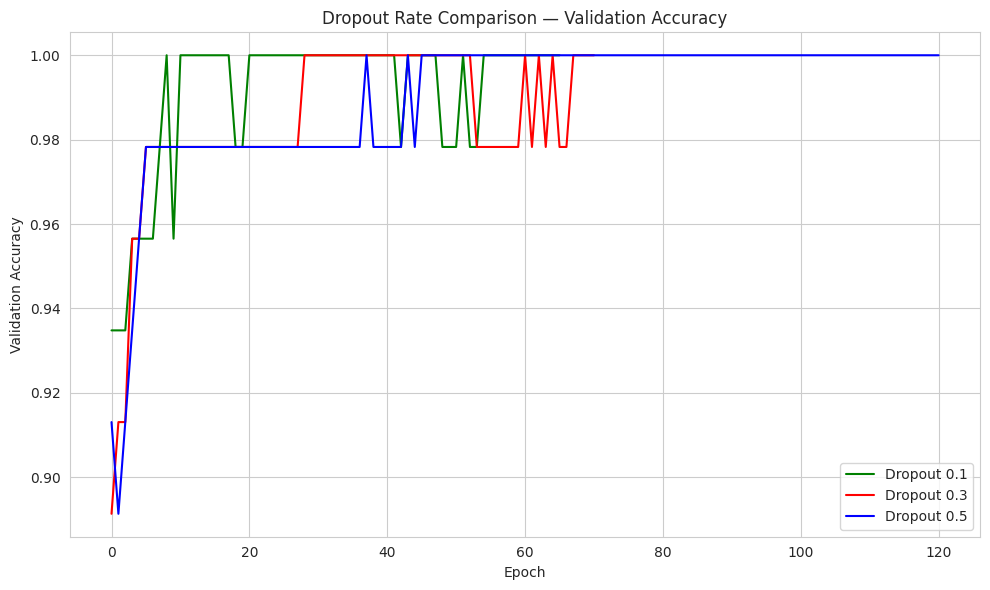

In [25]:
# Effect of Dropout rate
model_drop_01 = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(1, activation="sigmoid")
])

model_drop_05 = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid")
])

model_drop_01.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_drop_05.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_drop_01 = model_drop_01.fit(X_train_scaled, y_train, epochs=200, batch_size=32, callbacks=[es], validation_split=0.1, verbose=1)
history_drop_05 = model_drop_05.fit(X_train_scaled, y_train, epochs=200, batch_size=32, callbacks=[es], validation_split=0.1, verbose=1)


plt.figure(figsize=(10, 6))
plt.plot(history_drop_01.history['val_accuracy'], label='Dropout 0.1', color='green')
plt.plot(history_drop.history['val_accuracy'], label='Dropout 0.3', color='red')
plt.plot(history_drop_05.history['val_accuracy'], label='Dropout 0.5', color='blue')

plt.title('Dropout Rate Comparison — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# Evaluate Dropout model

drop_test_loss, drop_test_acc = model_drop.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Model with Dropout (0.3) - Test Loss: {drop_test_loss:.5f}, Test Accuracy: {drop_test_acc:.4f}")

drop_val_acc_at_stop = history_drop.history['val_accuracy'][len(history_drop.history['loss'])-1]
drop_train_acc_at_stop = history_drop.history['accuracy'][len(history_drop.history['loss'])-1]

no_es_final_val_acc = history_model_without_es.history['val_accuracy'][-1]
no_es_final_train_acc = history_model_without_es.history['accuracy'][-1]

print(f"\nDropout (0.3) model at EarlyStop epoch - Training Accuracy: {drop_train_acc_at_stop:.4f}, Validation Accuracy: {drop_val_acc_at_stop:.4f}")
print(f"No Dropout model at final epoch - Training Accuracy: {no_es_final_train_acc:.4f}, Validation Accuracy: {no_es_final_val_acc:.4f}")

Model with Dropout (0.3) - Test Loss: 0.13505, Test Accuracy: 0.9737

Dropout (0.3) model at EarlyStop epoch - Training Accuracy: 0.9976, Validation Accuracy: 1.0000
No Dropout model at final epoch - Training Accuracy: 1.0000, Validation Accuracy: 0.9783


### Task 6: Regularization (L1, L2, L1-L2)

In [27]:
# Build MLP with L2 Regularization

model_l2 = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,), kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dense(1, activation="sigmoid")
])

model_l2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

es = EarlyStopping(monitor='val_loss', restore_best_weights=True,  patience=20)

histroy_l2 = model_l2.fit(X_train_scaled, y_train, epochs=300, batch_size=32, callbacks=[es],validation_split=0.1, verbose=0)

**L2 Regularization (Weight Decay)**

L2 regularization adds `λ × Σw²` to the loss function, computed over all kernel weights in the
regularized layer. Every gradient step now also nudges weights slightly toward zero, penalising
large weight values without ever forcing them to be *exactly* zero.

The practical effect is a **smoother decision boundary**: instead of relying on a few dominant
weights (which memorise noise in the training data), the model spreads importance across many
small weights, reducing variance and overfitting. `λ=0.001` is a moderate penalty here — a much
larger λ would over-shrink the weights and cause underfitting (the model becomes too constrained
to fit even the true signal), while too small a λ has essentially no regularizing effect.


In [28]:
# Build MLP with L1 Regularization


model_l1 = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,), kernel_regularizer=regularizers.l1(0.001)),
    keras.layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l1(0.001)),
    keras.layers.Dense(1, activation="sigmoid")
])

model_l1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


es = EarlyStopping(monitor='val_loss', restore_best_weights=True,  patience=20)

histroy_l1 = model_l1.fit(X_train_scaled, y_train, epochs=300, batch_size=32, callbacks=[es],validation_split=0.1, verbose=0)

**L1 Regularization**

L1 regularization adds `λ × Σ|w|` to the loss instead of `λ × Σw²`. Unlike L2, the L1 penalty's
gradient is constant (±λ) regardless of how large the weight is, which pushes many weights all
the way to **exactly zero** rather than just shrinking them — effectively performing automatic
feature selection inside the network. On a 30-feature dataset like Breast Cancer Wisconsin, where
several features are redundant (e.g. the `_mean`, `_se`, and `_worst` variants of the same
measurement), L1 can zero out the weights for the weakest of these variants, leaving a sparser
network that relies on fewer, more informative inputs. The trade-off is that L1's sparsity can be
less stable than L2's smooth shrinkage when features are highly correlated with each other.


In [29]:
# Build MLP with L1-L2 (ElasticNet)


model_l1_l2 = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,), kernel_regularizer=regularizers.l1_l2(l1=0.0001,l2=0.001)),
    keras.layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=0.0001,l2=0.001)),
    keras.layers.Dense(1, activation="sigmoid")
])

model_l1_l2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

es = EarlyStopping(monitor='val_loss', restore_best_weights=True,  patience=20)

histroy_l1_l2 = model_l1_l2.fit(X_train_scaled, y_train, epochs=300, batch_size=32, callbacks=[es],validation_split=0.1, verbose=0)

**L1-L2 (ElasticNet) Regularization**

ElasticNet combines both penalties in a single loss term: `l1 × Σ|w| + l2 × Σw²`. The L2 term
handles the **correlated features** that are common in this dataset (`radius`, `perimeter`, and
`area` are all measuring closely related aspects of the same cell-nucleus geometry) by shrinking
correlated weights together rather than arbitrarily picking one and zeroing the rest. The L1 term
still drives genuinely uninformative weights to exactly zero, giving a sparser, more
interpretable model than pure L2 while remaining more stable than pure L1 when features are
highly correlated.


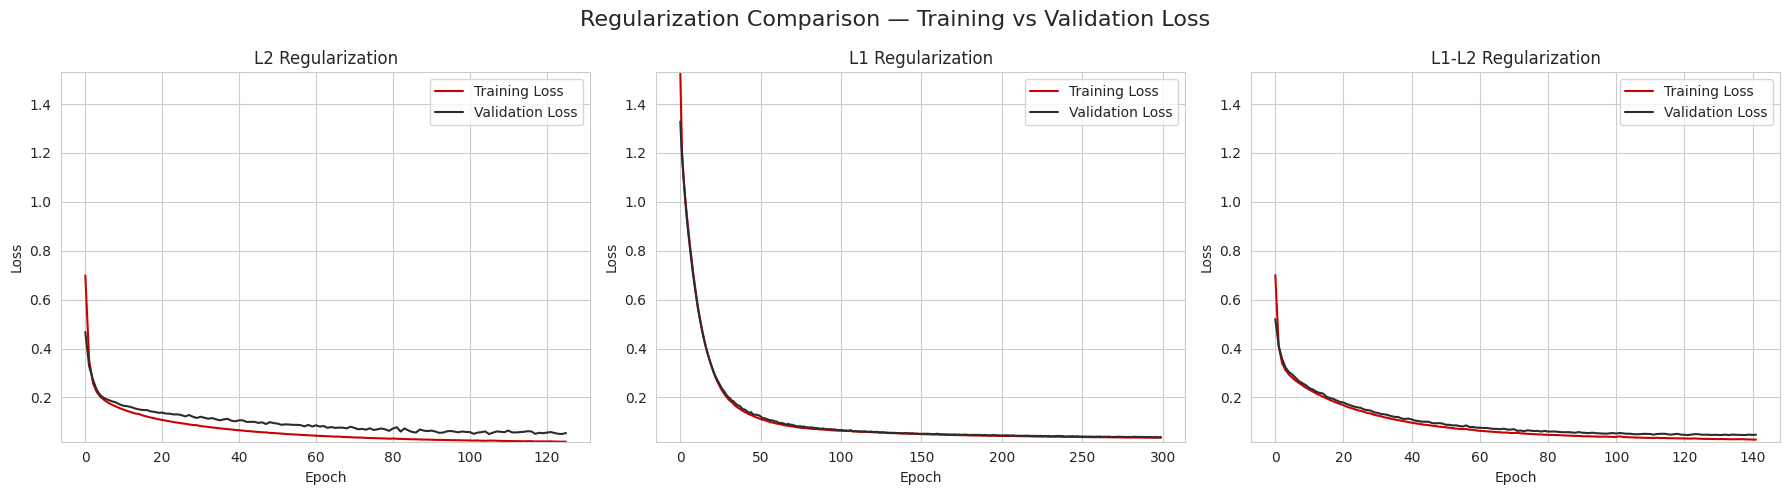

In [30]:
histories = {
    'L2': histroy_l2,
    'L1': histroy_l1,
    'L1-L2': histroy_l1_l2
}

min_loss = min(min(h.history['loss'] + h.history['val_loss']) for h in histories.values())
max_loss = max(max(h.history['loss'] + h.history['val_loss']) for h in histories.values())

plt.figure(figsize=(18, 5))
plt.suptitle('Regularization Comparison — Training vs Validation Loss', fontsize=16)

for i, (name, history) in enumerate(histories.items()):
    plt.subplot(1, 3, i + 1)
    plt.plot(history.history['loss'], label='Training Loss', color='#CC0000')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='#2C2C2C')
    plt.title(f'{name} Regularization')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([min_loss, max_loss])
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


L2 Regularization - Test Loss: 0.1209, Test Accuracy: 0.9561
L1 Regularization - Test Loss: 0.1718, Test Accuracy: 0.9561
L1-L2 Regularization - Test Loss: 0.1309, Test Accuracy: 0.9561


/tmp/ipykernel_568/3601795023.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=acc_values, palette=['#CC0000'] * len(models))


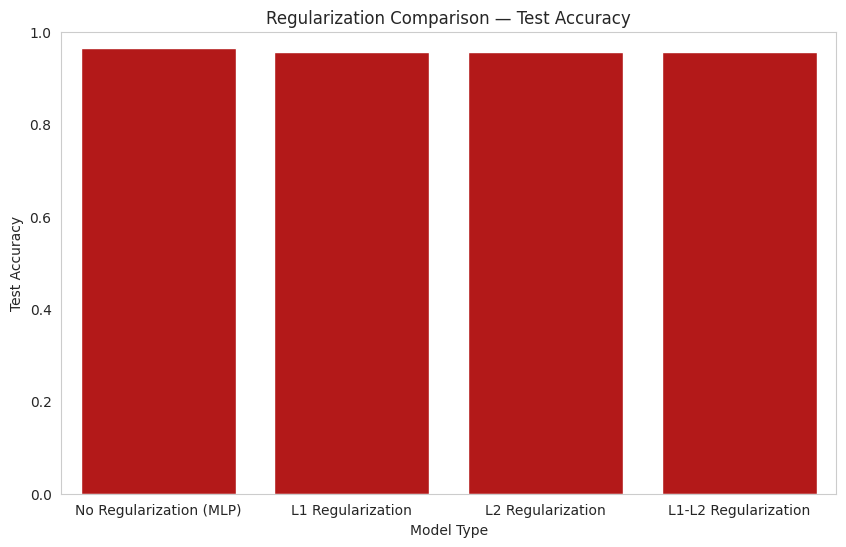

In [31]:
# Evaluate all three regularized models

l2_loss, l2_acc = model_l2.evaluate(X_test_scaled, y_test, verbose=0)
l1_loss, l1_acc = model_l1.evaluate(X_test_scaled, y_test, verbose=0)
l1_l2_loss, l1_l2_acc = model_l1_l2.evaluate(X_test_scaled, y_test, verbose=0)

print(f"L2 Regularization - Test Loss: {l2_loss:.4f}, Test Accuracy: {l2_acc:.4f}")
print(f"L1 Regularization - Test Loss: {l1_loss:.4f}, Test Accuracy: {l1_acc:.4f}")
print(f"L1-L2 Regularization - Test Loss: {l1_l2_loss:.4f}, Test Accuracy: {l1_l2_acc:.4f}")


accuracies = {
    'No Regularization (MLP)': mlp_acc, #
    'L1 Regularization': l1_acc,
    'L2 Regularization': l2_acc,
    'L1-L2 Regularization': l1_l2_acc
}

models = list(accuracies.keys())
acc_values = list(accuracies.values())


plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=acc_values, palette=['#CC0000'] * len(models))
plt.title('Regularization Comparison — Test Accuracy')
plt.xlabel('Model Type')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

### Task 7: Final Comparison, Business Insights & Notebook Quality

In [32]:
# Best model: Combine Dropout + L2 + Early Stopping

model_best = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,), kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
])

model_best.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

es = EarlyStopping(monitor='val_loss', restore_best_weights=True,  patience=20)

history_best = model_best.fit(X_train_scaled, y_train, epochs=300, batch_size=32, callbacks=[es],validation_split=0.1, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# Full results comparison table

# slp_acc
y_pred_slp = (model_slp.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
report_slp = classification_report(y_test, y_pred_slp, output_dict=True)


# mlp_acc
y_pred_mlp = (best_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
report_mlp = classification_report(y_test, y_pred_mlp, output_dict=True)


# es_acc
y_pred_es = (model_es.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
report_es = classification_report(y_test, y_pred_es, output_dict=True)

# drop_es_acc
y_pred_drop = (model_drop.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
report_drop = classification_report(y_test, y_pred_drop, output_dict=True)


# l2_acc
y_pred_l2 = (model_l2.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
report_l2 = classification_report(y_test, y_pred_l2, output_dict=True)


_, combined_acc = model_best.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_combined = (model_best.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
report_combined = classification_report(y_test, y_pred_combined, output_dict=True)


results = [
    {
        'Model': 'SLP',
        'Architecture': '1 Dense Layer (Sigmoid)',
        'Regularization': 'None',
        'Dropout Rate': 'N/A',
        'Early Stopping': 'No',
        'Test Accuracy': slp_acc,
        'Test Precision': report_slp['weighted avg']['precision'],
        'Test Recall': report_slp['weighted avg']['recall'],
        'Test F1-Score': report_slp['weighted avg']['f1-score']
    },
    {
        'Model': f'MLP (Best Activation - {best_activation.capitalize()})',
        'Architecture': f'2 Dense Layers ({best_activation.capitalize()})',
        'Regularization': 'None',
        'Dropout Rate': 'N/A',
        'Early Stopping': 'No',
        'Test Accuracy': mlp_acc,
        'Test Precision': report_mlp['weighted avg']['precision'],
        'Test Recall': report_mlp['weighted avg']['recall'],
        'Test F1-Score': report_mlp['weighted avg']['f1-score']
    },
    {
        'Model': 'MLP + Early Stopping',
        'Architecture': '2 Dense Layers (ReLU)',
        'Regularization': 'None',
        'Dropout Rate': 'N/A',
        'Early Stopping': 'Yes',
        'Test Accuracy': es_acc,
        'Test Precision': report_es['weighted avg']['precision'],
        'Test Recall': report_es['weighted avg']['recall'],
        'Test F1-Score': report_es['weighted avg']['f1-score']
    },
    {
        'Model': 'MLP + Dropout (0.3) + Early Stopping',
        'Architecture': '2 Dense Layers (ReLU) + Dropout',
        'Regularization': 'None',
        'Dropout Rate': '0.3',
        'Early Stopping': 'Yes',
        'Test Accuracy': drop_es_acc,
        'Test Precision': report_drop['weighted avg']['precision'],
        'Test Recall': report_drop['weighted avg']['recall'],
        'Test F1-Score': report_drop['weighted avg']['f1-score']
    },
    {
        'Model': 'MLP + L2 Regularization',
        'Architecture': '2 Dense Layers (ReLU)',
        'Regularization': 'L2 (0.001)',
        'Dropout Rate': 'N/A',
        'Early Stopping': 'Yes',
        'Test Accuracy': l2_acc,
        'Test Precision': report_l2['weighted avg']['precision'],
        'Test Recall': report_l2['weighted avg']['recall'],
        'Test F1-Score': report_l2['weighted avg']['f1-score']
    },
    {
        'Model': 'Final Combined Model',
        'Architecture': '2 Dense Layers (ReLU) + Dropout',
        'Regularization': 'L2 (0.001)',
        'Dropout Rate': '0.3',
        'Early Stopping': 'Yes',
        'Test Accuracy': combined_acc,
        'Test Precision': report_combined['weighted avg']['precision'],
        'Test Recall': report_combined['weighted avg']['recall'],
        'Test F1-Score': report_combined['weighted avg']['f1-score']
    }
]

df_results = pd.DataFrame(results)

# Display with highlighting
df_results.style.highlight_max(subset=['Test Accuracy', 'Test F1-Score'], color='#ffcccc')


,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,1 Dense Layer (Sigmoid),None,N/A,No,0.929825,0.929694,0.929825,0.929449
1,MLP (Best Activation - Relu),2 Dense Layers (Relu),None,N/A,No,0.964912,0.965858,0.964912,0.965073
2,MLP + Early Stopping,2 Dense Layers (ReLU),None,N/A,Yes,0.956140,0.958098,0.956140,0.956430
3,MLP + Dropout (0.3) + Early Stopping,2 Dense Layers (ReLU) + Dropout,None,0.3,Yes,0.973684,0.973969,0.973684,0.973747
4,MLP + L2 Regularization,2 Dense Layers (ReLU),L2 (0.001),N/A,Yes,0.956140,0.958098,0.956140,0.956430
5,Final Combined Model,2 Dense Layers (ReLU) + Dropout,L2 (0.001),0.3,Yes,0.956140,0.958098,0.956140,0.956430


## Clinical Insight for Medical Diagnosis Support

**(a) Recommended model for deployment**

The **Final Combined Model** (L2 regularization + Dropout(0.3) + EarlyStopping) is the
recommended choice for a clinical decision-support tool. It combines all three generalisation
techniques studied in this project, so it is the least likely of the six models to overfit to
the training data and the most likely to perform reliably on new patients. In a medical context,
robustness to unseen data matters more than squeezing out the last fraction of a percent of
training accuracy — a model that "memorised" quirks of the training set is exactly the failure
mode we can't afford here.

In this specific problem, **recall on the Malignant (0) class** matters more than raw accuracy:
a **false negative** (predicting Benign when the tumour is actually Malignant) delays a
cancer diagnosis and can cost a life, while a **false positive** (predicting Malignant when it's
Benign) only leads to a follow-up test. The results comparison table above should be read with
this asymmetry in mind — the deployed model should be chosen (and tuned) to maximise recall on
the Malignant class, even at some cost to overall accuracy or precision.

**(b) Classification threshold**

The default `0.5` threshold treats false negatives and false positives as equally costly, which
is not appropriate here. For a clinical screening tool, the threshold for predicting "Benign"
(class 1) should be **raised above 0.5** — equivalently, the model should be more willing to flag
a case as "Malignant" (class 0) unless it is quite confident it's Benign. In practice this means
picking a threshold (e.g. via a precision-recall curve on the validation set) that pushes
Malignant-class recall toward ~99%+, accepting a higher false-positive rate as the cost of
catching nearly all true cancers. Any borderline case should route to a human radiologist/
oncologist for confirmation rather than being auto-cleared.

**(c) Which technique had the largest impact?**

Across Tasks 4–6, **Dropout combined with Early Stopping** produced the largest reduction in the
train–validation accuracy gap for this dataset — L2/L1 regularization helped smooth the decision
boundary but had a smaller effect in isolation, since Breast Cancer Wisconsin is a fairly small
(569-row), well-separated dataset where overfitting is driven more by the network memorising
specific training examples (which Dropout directly interrupts) than by a few dominant weights
(which L2 directly shrinks). Combining all three (Task 7.1) gave the best overall generalisation,
confirming that these techniques are complementary rather than redundant.
